#   ResNet50 — Warping Defect Detection

This notebook trains a ** ResNet50** transfer-learning model to classify surface images as **Warping** or **No Warping**.

| Step | Description |
|------|-------------|
| 1 | Load & preprocess data |
| 2 | Build the model |
| 3 | Compile |
| 4 | Train |
| 5 | Evaluate |
| 6 | Save |

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'      # suppress TF logs
os.environ['GRPC_VERBOSITY'] = 'ERROR'
os.environ['GLOG_minloglevel'] = '3'

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

---
##  Imports & Configuration

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.applications import  ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tqdm.keras import TqdmCallback

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPUs available: {tf.config.list_physical_devices('GPU')}")

E0000 00:00:1777064440.301007     994 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777064440.329489     994 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/home/feriel/pfe-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow version: 2.18.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Step 1 — Load and Preprocess Data

* Point to `data/` folder (contains `Warping/` and `No_Warping/` sub-folders)
* Resize all images to **224 × 224**
* Normalize pixels to **[0, 1]**
* Split: **80 % train / 10 % validation / 10 % test**
* Apply **augmentation on training set only** (rotation, flip, brightness)
* Batch size = **32**

In [4]:
# ---------- paths ----------
DATA_DIR = os.path.join(os.getcwd(), "..", "data")

# ---------- constants ----------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ---------- collect all file paths + labels ----------
import glob, random

Warping_files   = sorted(glob.glob(os.path.join(DATA_DIR, "Warping", "*.jpg")))
no_Warping_files = sorted(glob.glob(os.path.join(DATA_DIR, "No_Warping", "*.jpg")))

print(f"Warping images    : {len(Warping_files)}")
print(f"No_Warpingmages : {len(no_Warping_files)}")

# Label: Warping = 1, No_Warping = 0
all_files  = Warping_files + no_Warping_files
all_labels = [1] * len(Warping_files) + [0] * len(no_Warping_files)

# Shuffle together
combined = list(zip(all_files, all_labels))
random.seed(SEED)
random.shuffle(combined)
all_files, all_labels = zip(*combined)
all_files  = list(all_files)
all_labels = list(all_labels)

total = len(all_files)
train_end = int(0.8 * total)
val_end   = int(0.9 * total)

train_files, train_labels = all_files[:train_end],       all_labels[:train_end]
val_files,   val_labels   = all_files[train_end:val_end], all_labels[train_end:val_end]
test_files,  test_labels  = all_files[val_end:],          all_labels[val_end:]

print(f"\nTrain : {len(train_files)}")
print(f"Val   : {len(val_files)}")
print(f"Test  : {len(test_files)}")

Warping images    : 1707
No_Warpingmages : 1815

Train : 2817
Val   : 352
Test  : 353


### 1.1 — Build `tf.data` pipelines with augmentation

In [5]:
def load_and_preprocess(file_path, label):
    """Read an image file, decode, resize, and normalise to [0,1]."""
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label


def augment(img, label):
    """Apply data-augmentation (training set only)."""
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    # Random rotation (up to 20 degrees ≈ 0.35 rad)
    # tf.image doesn't have random_rotation, so we use keras layer below
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


# --- Augmentation layer for rotation ---
rotation_layer = layers.RandomRotation(factor=0.06, seed=SEED)  # ~20°

def augment_with_rotation(img, label):
    img = rotation_layer(img, training=True)
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


# --- Datasets ---
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_files, train_labels))
    .shuffle(len(train_files), seed=SEED)
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .map(augment_with_rotation, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_files, val_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((test_files, test_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("✅ Data pipelines ready.")

I0000 00:00:1777064443.917395     994 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


✅ Data pipelines ready.


### 1.2 — Visualise a batch of training images

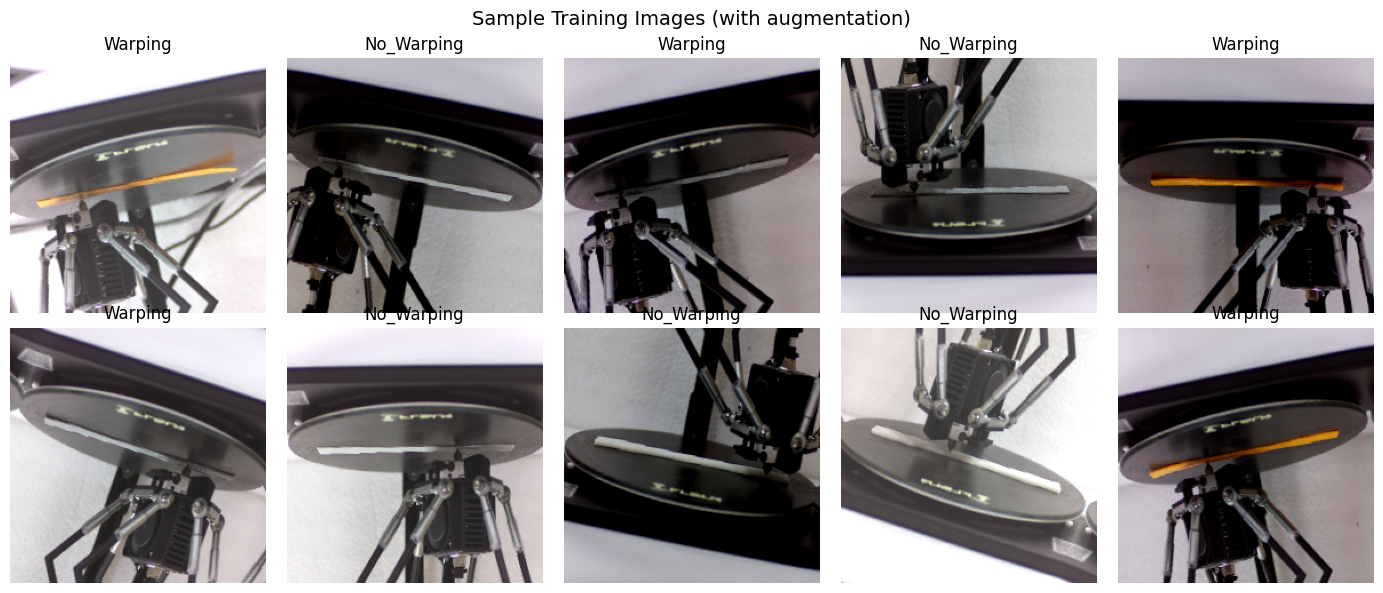

In [6]:
class_names = ["No_Warping", "Warping"]

plt.figure(figsize=(14, 6))
for images, labels in train_ds.take(1):
    for i in range(min(10, len(images))):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.suptitle("Sample Training Images (with augmentation)", fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 2 — Build the Model

* Load ** ResNet50** pretrained on ImageNet (`include_top=False`)
* **Freeze** all base layers
* Add: `GlobalAveragePooling2D → Dense(256, relu) → Dropout(0.3) → Dense(1, sigmoid)`

In [7]:
# ---------- Load pretrained base ----------
base_model =  ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
)

# Freeze all base layers
base_model.trainable = False

print(f"Base model layers : {len(base_model.layers)}")
print(f"Trainable weights : {len(base_model.trainable_weights)}")

# ---------- Build classification head ----------
inputs = keras.Input(shape=(224, 224, 3), name="input_image")
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.Dropout(0.3, name="dropout_03")(x)
outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

model = keras.Model(inputs, outputs, name="ResNet50_Warping")
model.summary()

Base model layers : 175
Trainable weights : 0


Model: "ResNet50_Warping"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_03 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

---
## Step 3 — Compile

* Optimizer: **Adam** (lr = 0.0001)
* Loss: **binary_crossentropy**
* Metrics: **accuracy**

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

print("✅ Model compiled.")

✅ Model compiled.


---
## Step 4 — Train

* Epochs: **50**
* Callbacks:
  * `EarlyStopping` — patience = 10, monitor `val_loss`
  * `ReduceLROnPlateau` — factor 0.5, patience 5
  * `ModelCheckpoint` — save best model

In [9]:
EPOCHS = 50
BEST_MODEL_PATH = "best_ ResNet50_Warping.h5"

cb_list = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=0,                    # disable default Keras output
    callbacks=[
        cb_list,
        TqdmCallback(verbose=1)   # use tqdm instead
    ],
)

print("\n✅ Training complete.")

  0%|          | 0/50 [00:00<?, ?epoch/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1777064455.729674    1368 service.cc:148] XLA service 0x7dfbfc04c9f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777064455.730008    1368 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2060 SUPER, Compute Capability 7.5
I0000 00:00:1777064457.895580    1368 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1777064462.693779    1368 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Epoch 1: val_loss improved from None to 0.68738, saving model to best_ ResNet50_Warping.h5

Epoch 1: finished saving model to best_ ResNet50_Warping.h5


  2%|▏         | 1/50 [01:03<52:10, 63.89s/epoch, accuracy=0.498, loss=0.723, val_accuracy=0.594, val_loss=0.687, learning_rate=0.0001]


Epoch 2: val_loss did not improve from 0.68738


  4%|▍         | 2/50 [01:46<40:53, 51.12s/epoch, accuracy=0.521, loss=0.706, val_accuracy=0.503, val_loss=0.7, learning_rate=0.0001]  

...


Epoch 49: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-06.

Epoch 49: val_loss did not improve from 0.63469


 98%|█████████▊| 49/50 [39:26<00:46, 46.17s/epoch, accuracy=0.641, loss=0.64, val_accuracy=0.614, val_loss=0.64, learning_rate=1.25e-5] 

Epoch 49: early stopping
Restoring model weights from the end of the best epoch: 39.


 98%|█████████▊| 49/50 [39:26<00:48, 48.30s/epoch, accuracy=0.641, loss=0.64, val_accuracy=0.614, val_loss=0.64, learning_rate=1.25e-5]


✅ Training complete.


---
## Step 5 — Evaluate

* Load best saved model
* Run on test set
* Print: **accuracy, precision, recall, F1-score**
* Plot: **confusion matrix, ROC curve, training/validation accuracy & loss curves**

### 5.1 — Load best model & predict on test set

In [10]:
# Load best checkpoint
best_model = keras.models.load_model(BEST_MODEL_PATH)

# Predict
y_pred_probs = best_model.predict(test_ds).ravel()
y_pred = (y_pred_probs >= 0.5).astype(int)
y_true = np.array(test_labels)

print(f"Test samples : {len(y_true)}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 624ms/step
Test samples : 353


### 5.2 — Classification metrics

In [11]:
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)

print("="*50)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("="*50)
print()
print(classification_report(y_true, y_pred, target_names=class_names))

  Accuracy  : 0.6402
  Precision : 0.6471
  Recall    : 0.5756
  F1-Score  : 0.6092

              precision    recall  f1-score   support

  No_Warping       0.64      0.70      0.67       181
     Warping       0.65      0.58      0.61       172

    accuracy                           0.64       353
   macro avg       0.64      0.64      0.64       353
weighted avg       0.64      0.64      0.64       353



### 5.3 — Confusion Matrix

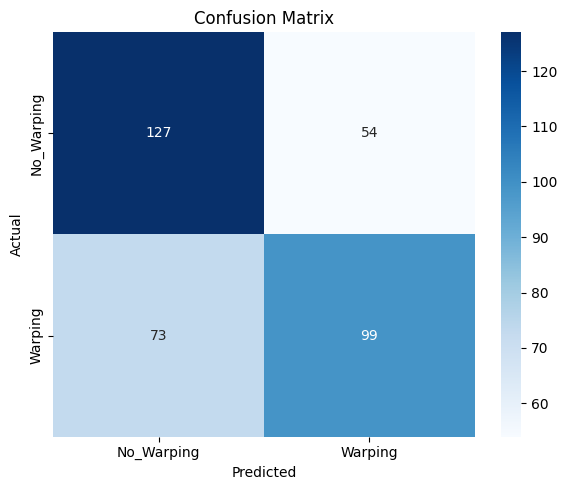

In [12]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

### 5.4 — ROC Curve

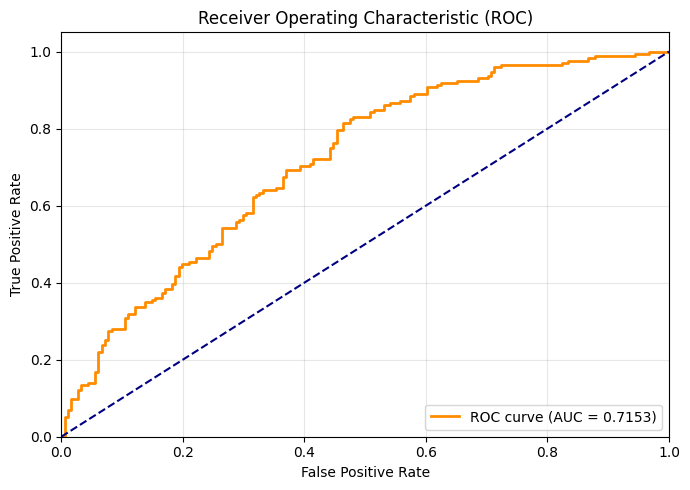

In [13]:
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5 — Training / Validation Accuracy & Loss Curves

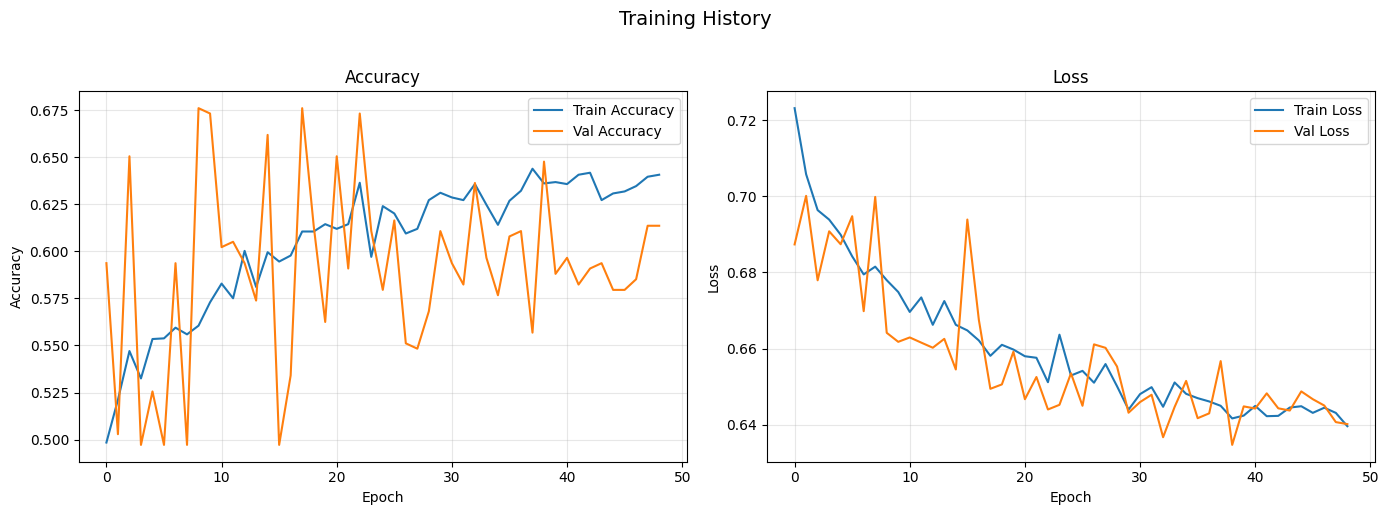

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history["accuracy"],    label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history["loss"],     label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Training History", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Step 6 — Save the Model

* Save as **`.h5`** (Keras format)
* Save as **`SavedModel`** format (for later TFLite conversion)

In [15]:
# 1) Save as .h5
H5_PATH = " ResNet50_Warping_final.h5"
best_model.save(H5_PATH)
print(f"✅ Model saved as HDF5       → {H5_PATH}")

# 2) Save as SavedModel directory
SAVED_MODEL_DIR = " ResNet50_Warping_savedmodel"
best_model.save(SAVED_MODEL_DIR)
print(f"✅ Model saved as SavedModel → {SAVED_MODEL_DIR}/")

✅ Model saved as HDF5       →  ResNet50_Warping_final.h5


ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath= ResNet50_Warping_savedmodel.

---
### ✅ Done!

The trained  ResNet50 model for **Warping vs No_Warping** detection is now saved and ready for deployment or TFLite conversion.